# 03 — Train LSTM Model

**Mục tiêu notebook này:**
1. Train LSTM model trên data đã preprocess từ notebook 02
2. Monitor training live: loss, accuracy, learning rate
3. Vẽ learning curve sau training
4. Quick sanity check trên val set
5. Hướng dẫn bước tiếp theo: `evaluate.py`

**Yêu cầu:**
- `ml/data/processed/` đã có đủ 6 file `.npy` (chạy notebook 02 trước)
- Python 3.10/3.11, TensorFlow 2.15

**Thời gian ước tính:** 5–30 phút tùy CPU/GPU và kích thước dataset

> **Chạy từ terminal thay thế:**
> ```bash
> python ml/src/train.py
> ```

## 0. Setup & Import

In [13]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

ROOT = Path('../../')
ML_SRC = ROOT / 'ml' / 'src'
if str(ML_SRC) not in sys.path:
    sys.path.insert(0, str(ML_SRC))

PROCESSED_DIR = ROOT / 'ml' / 'data' / 'processed'
MODEL_DIR     = ROOT / 'ml' / 'models'
MODEL_PATH    = MODEL_DIR / 'lstm_v1.h5'

# Kiểm tra data đầu vào
missing = [f for f in ['X_train.npy','y_train.npy','X_val.npy','y_val.npy']
           if not (PROCESSED_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Thiếu file: {missing}\nChạy notebook 02 trước!')

print(f'ROOT          : {ROOT.resolve()}')
print(f'PROCESSED_DIR : {PROCESSED_DIR.resolve()}')
print(f'MODEL_DIR     : {MODEL_DIR.resolve()}')
print('Data files    : OK')

ROOT          : D:\CODE\Smart Insole
PROCESSED_DIR : D:\CODE\Smart Insole\ml\data\processed
MODEL_DIR     : D:\CODE\Smart Insole\ml\models
Data files    : OK


## 1. Kiểm tra GPU / CPU

TensorFlow tự chọn GPU nếu có. Với dataset GaitPDB (~vài nghìn windows),
CPU vẫn train được trong 10–20 phút.

In [14]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU khả dụng: {[g.name for g in gpus]}')
    print('→ Training sẽ dùng GPU')
else:
    print(f'CPU only: {[c.name for c in cpus]}')
    print('→ Training trên CPU (chậm hơn nhưng OK với dataset nhỏ)')

print(f'\nTensorFlow version: {tf.__version__}')

CPU only: ['/physical_device:CPU:0']
→ Training trên CPU (chậm hơn nhưng OK với dataset nhỏ)

TensorFlow version: 2.15.1


## 2. Load & Xem Lại Data

Load numpy arrays và in thống kê nhanh trước khi train.

In [15]:
X_train = np.load(PROCESSED_DIR / 'X_train.npy').astype(np.float32)
y_train = np.load(PROCESSED_DIR / 'y_train.npy').astype(np.int8)
X_val   = np.load(PROCESSED_DIR / 'X_val.npy').astype(np.float32)
y_val   = np.load(PROCESSED_DIR / 'y_val.npy').astype(np.int8)

CLASS_NAMES = ['Normal', 'Parkinson', 'Abnormal']

print(f'X_train : {X_train.shape}  dtype={X_train.dtype}')
print(f'X_val   : {X_val.shape}  dtype={X_val.dtype}')

for split_name, y in [('train', y_train), ('val', y_val)]:
    unique, counts = np.unique(y, return_counts=True)
    parts = [f'{CLASS_NAMES[int(u)]}={c}' for u, c in zip(unique, counts)]
    print(f'{split_name:5} classes: {" | ".join(parts)} (total={len(y)})')

print(f'\nX_train range: [{X_train.min():.4f}, {X_train.max():.4f}]')
print(f'X_val   range: [{X_val.min():.4f}, {X_val.max():.4f}]')

X_train : (22941, 100, 4)  dtype=float32
X_val   : (4916, 100, 4)  dtype=float32
train classes: Normal=7008 | Parkinson=15933 (total=22941)
val   classes: Normal=1501 | Parkinson=3415 (total=4916)

X_train range: [0.0000, 1.0000]
X_val   range: [0.0000, 1.0000]


## 3. Build Model

Import `build_lstm_model` từ `model.py`. Có thể thay đổi hyperparameter ở đây
mà không cần sửa file gốc.

In [16]:
import importlib
import model as model_module
importlib.reload(model_module)

from model import build_lstm_model, compute_class_weights, build_callbacks, CLASS_NAMES, N_CLASSES

# ── Hyperparameters ──────────────────────────────────────────────────────
LSTM_UNITS    = [64, 32]   # lớp 1: Bidirectional(64) → lớp 2: LSTM(32)
DROPOUT_RATE  = 0.3
L2_LAMBDA     = 1e-4
LEARNING_RATE = 1e-3
EPOCHS        = 100        # EarlyStopping sẽ dừng sớm hơn
BATCH_SIZE    = 32

model = build_lstm_model(
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    l2_lambda=L2_LAMBDA,
    learning_rate=LEARNING_RATE,
)

model.summary()
print(f'\nTổng parameters: {model.count_params():,}')

Model: "smart_insole_lstm"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sensor_input (InputLayer)   [(None, 100, 4)]          0         
                                                                 
 bi_lstm_1 (Bidirectional)   (None, 100, 128)          35328     
                                                                 
 bn_1 (BatchNormalization)   (None, 100, 128)          512       
                                                                 
 drop_1 (Dropout)            (None, 100, 128)          0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                20608     
                                                                 
 bn_2 (BatchNormalization)   (None, 32)                128       
                                                                 
 drop_2 (Dropout)            (None, 32)          

## 4. Class Weights — Xử lý Imbalance

GaitPDB có ít subject Parkinson hơn Control.  
Class weight tỉ lệ nghịch với tần suất — giúp model không bỏ qua class nhỏ.

In [17]:
class_weights = compute_class_weights(y_train, n_classes=N_CLASSES)

print('Class weights:')
for k, v in class_weights.items():
    name = CLASS_NAMES[k] if k < len(CLASS_NAMES) else f'class_{k}'
    bar = '█' * int(v * 10)
    print(f'  {k} {name:<12}: {v:.4f}  {bar}')

# Lưu để dùng lại khi fine-tune
MODEL_DIR.mkdir(parents=True, exist_ok=True)
with open(MODEL_DIR / 'class_weights.json', 'w') as f:
    json.dump(class_weights, f, indent=2)
print('\nSaved: ml/models/class_weights.json')

Class weights:
  0 Normal      : 1.6368  ████████████████
  1 Parkinson   : 0.7199  ███████

Saved: ml/models/class_weights.json


## 5. Callbacks

- **EarlyStopping** (patience=15): dừng nếu val_loss không giảm
- **ModelCheckpoint**: chỉ lưu khi val_loss tốt hơn
- **ReduceLROnPlateau** (patience=7): giảm LR × 0.5 khi plateau
- **TensorBoard**: log tại `ml/models/tensorboard_logs/`

In [18]:
LOG_DIR = MODEL_DIR / 'tensorboard_logs'

callbacks = build_callbacks(
    checkpoint_path=MODEL_PATH,
    log_dir=LOG_DIR,
    patience_early_stop=15,
    patience_lr=7,
    min_lr=1e-6,
)

print('Callbacks:')
for cb in callbacks:
    print(f'  {cb.__class__.__name__}')

print(f'\nModel sẽ lưu tại: {MODEL_PATH}')
print(f'TensorBoard logs: {LOG_DIR}')
print(f'\nXem TensorBoard (chạy trong terminal):')
print(f'  tensorboard --logdir {LOG_DIR.resolve()}')

Callbacks:
  EarlyStopping
  ModelCheckpoint
  ReduceLROnPlateau
  TensorBoard

Model sẽ lưu tại: ..\..\ml\models\lstm_v1.h5
TensorBoard logs: ..\..\ml\models\tensorboard_logs

Xem TensorBoard (chạy trong terminal):
  tensorboard --logdir D:\CODE\Smart Insole\ml\models\tensorboard_logs


## 6. Training

Cell dưới chạy `model.fit()`. Output sẽ hiển thị loss/accuracy từng epoch.

> **Tip:** Nếu muốn chạy nhanh hơn để test pipeline, giảm `EPOCHS = 10`
> ở section 3 và chạy lại từ đó.

In [19]:
import time

print(f'Bắt đầu training: tối đa {EPOCHS} epochs, batch={BATCH_SIZE}')
print(f'EarlyStopping patience=15 — training sẽ dừng sớm hơn nếu val_loss không giảm')
print('-' * 60)

t0 = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)

elapsed = time.time() - t0
print(f'\nTraining xong: {elapsed:.0f}s ({elapsed/60:.1f} phút)')

# Lưu history
history_path = MODEL_DIR / 'training_log.json'
with open(history_path, 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f, indent=2)
print(f'History saved: {history_path}')

Bắt đầu training: tối đa 100 epochs, batch=32
EarlyStopping patience=15 — training sẽ dừng sớm hơn nếu val_loss không giảm
------------------------------------------------------------
Epoch 1/100
717/717 [==============================] - ETA: 0s - loss: 0.7773 - accuracy: 0.6158 - top2_acc: 0.9731
Epoch 1: val_loss improved from inf to 0.66935, saving model to ..\..\ml\models\lstm_v1.h5
717/717 [==============================] - 57s 67ms/step - loss: 0.7773 - accuracy: 0.6158 - top2_acc: 0.9731 - val_loss: 0.6693 - val_accuracy: 0.6284 - val_top2_acc: 1.0000 - lr: 0.0010
Epoch 2/100
717/717 [==============================] - ETA: 0s - loss: 0.6077 - accuracy: 0.6873 - top2_acc: 0.9998
Epoch 2: val_loss did not improve from 0.66935
717/717 [==============================] - 47s 65ms/step - loss: 0.6077 - accuracy: 0.6873 - top2_acc: 0.9998 - val_loss: 0.7866 - val_accuracy: 0.5431 - val_top2_acc: 1.0000 - lr: 0.0010
Epoch 3/100
717/717 [==============================] - ETA: 0s - loss:

KeyboardInterrupt: 

## 7. Learning Curve

Vẽ loss + accuracy theo epoch. Đường train và val nên hội tụ gần nhau.  
Gap lớn giữa train/val → overfitting → tăng dropout hoặc giảm model size.

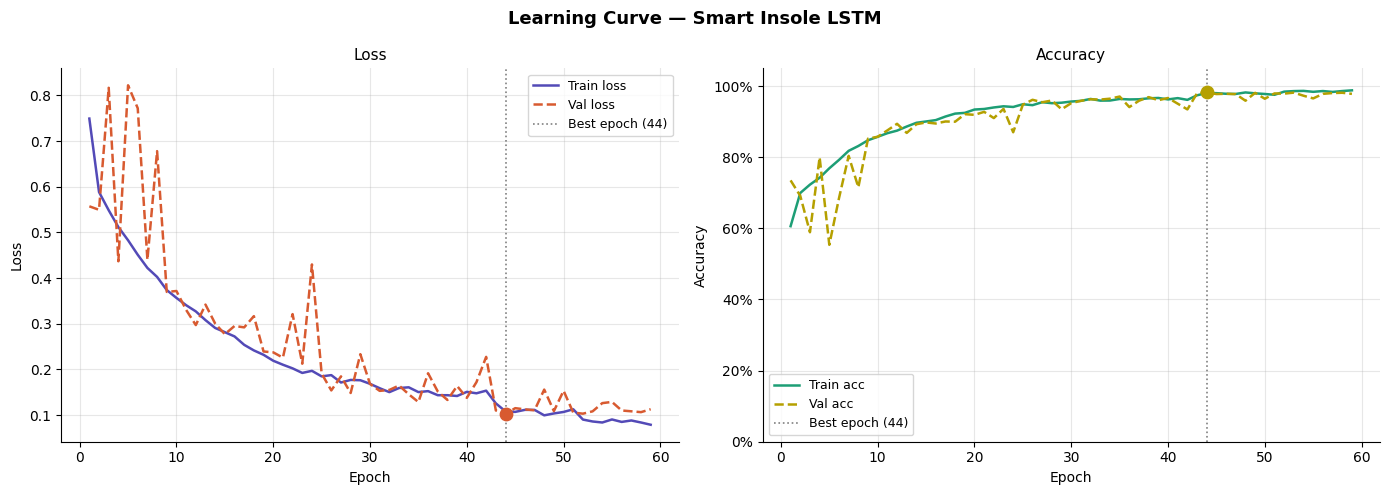

Saved: ..\..\ml\models\learning_curve.png


In [ ]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)
best_epoch = int(np.argmin(hist['val_loss'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve — Smart Insole LSTM', fontsize=13, fontweight='bold')

# ── Loss ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_ran, hist['loss'],     '#534AB7', linewidth=1.8, label='Train loss')
ax.plot(epochs_ran, hist['val_loss'], '#D85A30', linewidth=1.8, label='Val loss', linestyle='--')
ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.2, label=f'Best epoch ({best_epoch})')
ax.scatter([best_epoch], [hist['val_loss'][best_epoch-1]],
           color='#D85A30', s=80, zorder=5)
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('Loss', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# ── Accuracy ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_ran, hist['accuracy'],     '#1D9E75', linewidth=1.8, label='Train acc')
ax.plot(epochs_ran, hist['val_accuracy'], '#B5A000', linewidth=1.8, label='Val acc', linestyle='--')
ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.2, label=f'Best epoch ({best_epoch})')
ax.scatter([best_epoch], [hist['val_accuracy'][best_epoch-1]],
           color='#B5A000', s=80, zorder=5)
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_title('Accuracy', fontsize=11)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
curve_path = MODEL_DIR / 'learning_curve.png'
plt.savefig(curve_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {curve_path}')

## 8. Learning Rate Schedule

Kiểm tra `ReduceLROnPlateau` đã hoạt động chưa.  
LR nên giảm dần theo bậc thang khi val_loss plateau.

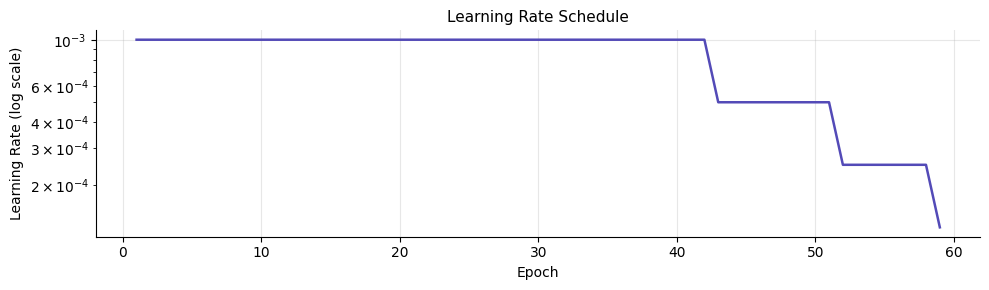

LR thay đổi: 1.00e-03 → 1.25e-04


In [ ]:
if 'lr' in hist:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.semilogy(epochs_ran, hist['lr'], '#534AB7', linewidth=1.8)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Learning Rate (log scale)', fontsize=10)
    ax.set_title('Learning Rate Schedule', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'lr_schedule.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'LR thay đổi: {hist["lr"][0]:.2e} → {hist["lr"][-1]:.2e}')
else:
    print('Không có LR log trong history (TF version cũ). Kiểm tra ReduceLROnPlateau log phía trên.')

## 9. Kết quả Tốt nhất

In [ ]:
best_val_loss = min(hist['val_loss'])
best_val_acc  = hist['val_accuracy'][best_epoch - 1]

# Top-2 accuracy nếu có
top2_key = next((k for k in hist if 'top2' in k and 'val' in k), None)
top2_str = f"{hist[top2_key][best_epoch-1]*100:.1f}%" if top2_key else 'N/A'

print('=' * 55)
print('  KẾT QUẢ TRAINING TỐT NHẤT')
print('=' * 55)
print(f'  Epoch thực tế    : {len(hist["val_loss"])}')
print(f'  Best epoch       : {best_epoch}')
print(f'  Val loss         : {best_val_loss:.4f}')
print(f'  Val accuracy     : {best_val_acc*100:.1f}%')
print(f'  Val top-2 acc    : {top2_str}')
print(f'  Model saved      : {MODEL_PATH}')
print('=' * 55)

# Nhận xét nhanh
if best_val_acc >= 0.85:
    print('\n✅ Accuracy >= 85% — kết quả tốt cho dataset y tế')
elif best_val_acc >= 0.70:
    print('\n⚠  Accuracy 70–85% — chấp nhận được, xem evaluate.py để phân tích F1 từng class')
else:
    print('\n❌ Accuracy < 70% — xem xét: thêm data, điều chỉnh hyperparameter, kiểm tra preprocessing')

  KẾT QUẢ TRAINING TỐT NHẤT
  Epoch thực tế    : 59
  Best epoch       : 44
  Val loss         : 0.1024
  Val accuracy     : 98.3%
  Val top-2 acc    : 100.0%
  Model saved      : ..\..\ml\models\lstm_v1.h5

✅ Accuracy >= 85% — kết quả tốt cho dataset y tế


## 10. Quick Sanity Check trên Val Set

Chạy nhanh classification report trên val set bằng model vừa train.  
Đây là xem sơ bộ — đánh giá chính thức dùng `evaluate.py` trên **test set**.

Classification Report — Val Set:
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97      1501
   Parkinson       0.99      0.98      0.99      3415

    accuracy                           0.98      4916
   macro avg       0.98      0.98      0.98      4916
weighted avg       0.98      0.98      0.98      4916



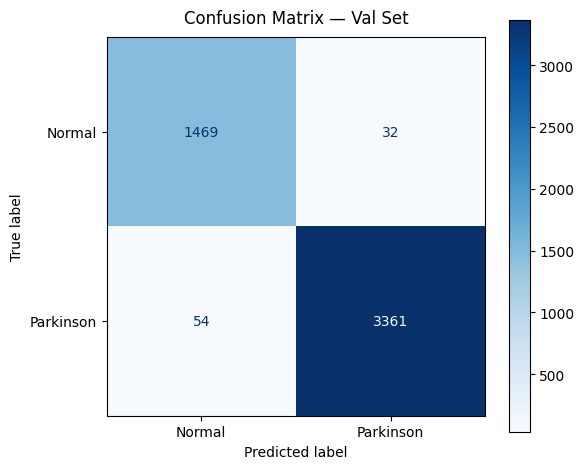

Saved: ml/models/val_confusion_matrix.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_proba = model.predict(X_val, batch_size=64, verbose=0)
y_pred  = np.argmax(y_proba, axis=1).astype(np.int8)

print('Classification Report — Val Set:')
present_classes = sorted(np.unique(np.concatenate([y_val, y_pred])).tolist())
target_names = [CLASS_NAMES[i] for i in present_classes]
print(classification_report(y_val, y_pred, labels=present_classes,
                             target_names=target_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred, labels=present_classes)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=0)
ax.set_title('Confusion Matrix — Val Set', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'val_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: ml/models/val_confusion_matrix.png')

## 11. Verify Model Đã Lưu trên Disk

Load lại từ file `.h5` và predict thử — đảm bảo model save/load không bị lỗi.  
Đây là bước quan trọng trước khi deploy vào backend.

In [ ]:
from model import load_trained_model

if not MODEL_PATH.exists():
    print(f'❌ Không tìm thấy {MODEL_PATH}')
else:
    model_loaded = load_trained_model(MODEL_PATH)
    print(f'Model loaded từ: {MODEL_PATH}')

    # So sánh output của model gốc và model load lại
    sample = X_val[:8]
    out_orig   = model.predict(sample, verbose=0)
    out_loaded = model_loaded.predict(sample, verbose=0)

    max_diff = np.abs(out_orig - out_loaded).max()
    print(f'Max output diff (orig vs loaded): {max_diff:.2e}')

    if max_diff < 1e-5:
        print('✅ Model save/load OK — output khớp hoàn toàn')
    else:
        print(f'⚠  Có sai khác nhỏ {max_diff:.2e} — có thể do floating point, kiểm tra lại')

## 12. Tóm tắt & Bước Tiếp Theo

### Files đã tạo:
```
ml/models/
├── lstm_v1.h5                ← model tốt nhất (theo val_loss)
├── training_log.json         ← history loss/accuracy mỗi epoch
├── class_weights.json        ← class weights dùng lại khi fine-tune
├── learning_curve.png
├── lr_schedule.png
└── val_confusion_matrix.png  ← sơ bộ, chưa phải đánh giá chính thức
```

### Diễn giải learning curve:
| Pattern | Ý nghĩa | Giải pháp |
|---|---|---|
| Train loss giảm, val loss tăng | Overfitting | Tăng dropout, giảm LSTM units |
| Cả hai đều không giảm | Underfitting / LR sai | Giảm L2, tăng LR |
| Cả hai giảm đều & gần nhau | **Lý tưởng** ✅ | — |
| Val loss plateau sớm | Data ít hoặc noise | Thêm data, data augmentation |

### Bước tiếp theo:
→ **`python ml/src/evaluate.py`** — đánh giá chính thức trên **test set** (chưa dùng lần nào)

In [ ]:
print('=' * 55)
print('  TRAINING HOÀN TẤT')
print('=' * 55)
print(f'  Model     : {MODEL_PATH}')
print(f'  Val acc   : {best_val_acc*100:.1f}%  |  Val loss: {best_val_loss:.4f}')
print(f'  Epochs    : {len(hist["val_loss"])} / {EPOCHS}')
print(f'  Best epoch: {best_epoch}')
print('=' * 55)
print()
print('Bước tiếp theo:')
print('  python ml/src/evaluate.py')
print()
print('Hoặc dùng model ngay:')
print('  from inference import InferenceEngine')
print('  engine = InferenceEngine()')
print('  result = engine.predict(raw_adc_window)')